DATASET LINK:  https://www.kaggle.com/datasets/brenda89/fifa-world-cup-2022

TUTORIALS FOLLOWED: https://www.kaggle.com/datasets/brenda89/fifa-world-cup-2022/code

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#importing pandas to read csv file
import pandas as pd
import numpy as np

#for figures
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [ ]:
#uploading and reading dataset
fifa2022= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data for Assessment/international_matches.csv', parse_dates = ['date'])


In [ ]:
fifa2022.head()

,date,home_team,away_team,home_team_continent,away_team_continent,home_team_fifa_rank,away_team_fifa_rank,home_team_total_fifa_points,away_team_total_fifa_points,home_team_score,...,shoot_out,home_team_result,home_team_goalkeeper_score,away_team_goalkeeper_score,home_team_mean_defense_score,home_team_mean_offense_score,home_team_mean_midfield_score,away_team_mean_defense_score,away_team_mean_offense_score,away_team_mean_midfield_score
0,1993-08-08,Bolivia,Uruguay,South America,South America,59,22,0,0,3,...,No,Win,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1993-08-08,Brazil,Mexico,South America,North America,8,14,0,0,1,...,No,Draw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1993-08-08,Ecuador,Venezuela,South America,South America,35,94,0,0,5,...,No,Win,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1993-08-08,Guinea,Sierra Leone,Africa,Africa,65,86,0,0,1,...,No,Win,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1993-08-08,Paraguay,Argentina,South America,South America,67,5,0,0,1,...,No,Lose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
fifa2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23921 entries, 0 to 23920
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   date                           23921 non-null  datetime64[ns]
 1   home_team                      23921 non-null  object        
 2   away_team                      23921 non-null  object        
 3   home_team_continent            23921 non-null  object        
 4   away_team_continent            23921 non-null  object        
 5   home_team_fifa_rank            23921 non-null  int64         
 6   away_team_fifa_rank            23921 non-null  int64         
 7   home_team_total_fifa_points    23921 non-null  int64         
 8   away_team_total_fifa_points    23921 non-null  int64         
 9   home_team_score                23921 non-null  int64         
 10  away_team_score                23921 non-null  int64         
 11  tournament     

In [ ]:
#checking null values
fifa2022.isnull().sum()

date                                 0
home_team                            0
away_team                            0
home_team_continent                  0
away_team_continent                  0
home_team_fifa_rank                  0
away_team_fifa_rank                  0
home_team_total_fifa_points          0
away_team_total_fifa_points          0
home_team_score                      0
away_team_score                      0
tournament                           0
city                                 0
country                              0
neutral_location                     0
shoot_out                            0
home_team_result                     0
home_team_goalkeeper_score       15542
away_team_goalkeeper_score       15826
home_team_mean_defense_score     16134
home_team_mean_offense_score     15411
home_team_mean_midfield_score    15759
away_team_mean_defense_score     16357
away_team_mean_offense_score     15609
away_team_mean_midfield_score    15942
dtype: int64

#DATA ANALYSIS

In [ ]:
fifa2022_teams = ['Qatar', 'Ecuador', 'Senegal', 'Netherlands',
                  'England', 'IR Iran', 'USA', 'Wales',
                  'Argentina', 'Saudi Arabia', 'Mexico', 'Poland',
                  'France', 'Australia', 'Denmark', 'Tunisia',
                  'Spain', 'Costa Rica', 'Germany', 'Japan',
                  'Belgium', 'Canada', 'Morocco', 'Croatia',
                  'Brazil', 'Serbia', 'Switzerland', 'Cameroon',
                  'Portugal', 'Ghana', 'Uruguay', 'Korea Republic']

In [ ]:
defence_score = []
for x in fifa2022_teams:
    df_score = np.round((fifa2022[fifa2022["home_team"]==x]['home_team_mean_defense_score'].mean() + 
                         fifa2022[fifa2022["away_team"]==x]['away_team_mean_defense_score'].mean())/2, 2)
    defence_score.append(df_score)
defence_scores = pd.DataFrame({'Team':fifa2022_teams, 'Df score': defence_score}).sort_values('Df score', ascending=False).reset_index(drop=True)
defence_scores.index += 1
defence_scores[:10]

,Team,Df score
1,Brazil,85.94
2,Spain,85.51
3,Germany,84.69
4,England,84.69
5,France,84.09
6,Argentina,83.00
7,Portugal,82.89
8,Belgium,81.23
9,Netherlands,80.73
10,Serbia,80.23


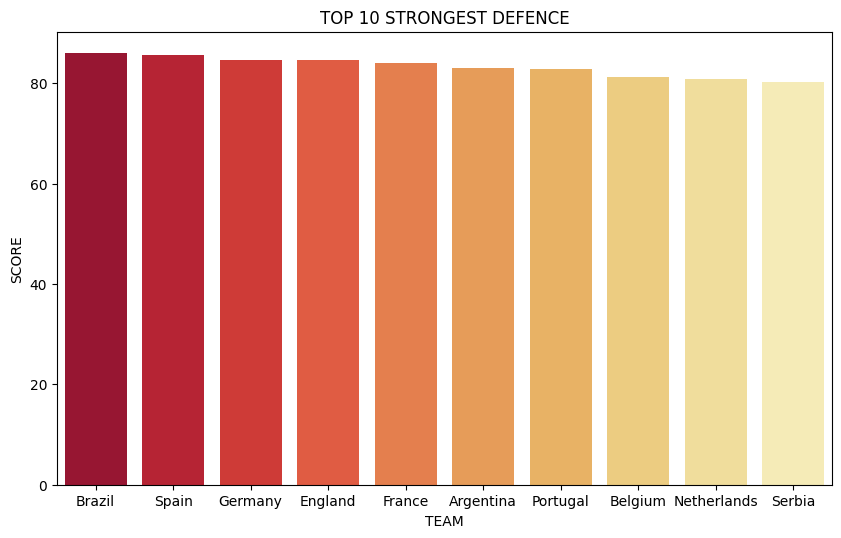

In [ ]:
plt.figure(figsize=(10,6), dpi=100)
ax = sns.barplot(data=defence_scores[:10], x='Team', y='Df score', palette='YlOrRd_r')
plt.xlabel('TEAM')
plt.ylabel('SCORE')
plt.title('TOP 10 STRONGEST DEFENCE');

In [ ]:
offence_score = []
for x in fifa2022_teams:
    of_score = np.round((fifa2022[fifa2022["home_team"]==x]['home_team_mean_offense_score'].mean() + 
                         fifa2022[fifa2022["away_team"]==x]['away_team_mean_offense_score'].mean())/2, 2)
    offence_score.append(of_score)

offence_scores = pd.DataFrame({'Team':fifa2022_teams, 'Of score': offence_score}).sort_values('Of score', ascending=False).reset_index(drop=True)
offence_scores.index += 1
offence_scores[:10]

,Team,Of score
1,Argentina,88.25
2,Brazil,86.55
3,Spain,85.87
4,France,85.70
5,Netherlands,85.47
6,England,85.09
7,Portugal,84.93
8,Uruguay,83.60
9,Germany,83.59
10,Belgium,81.71


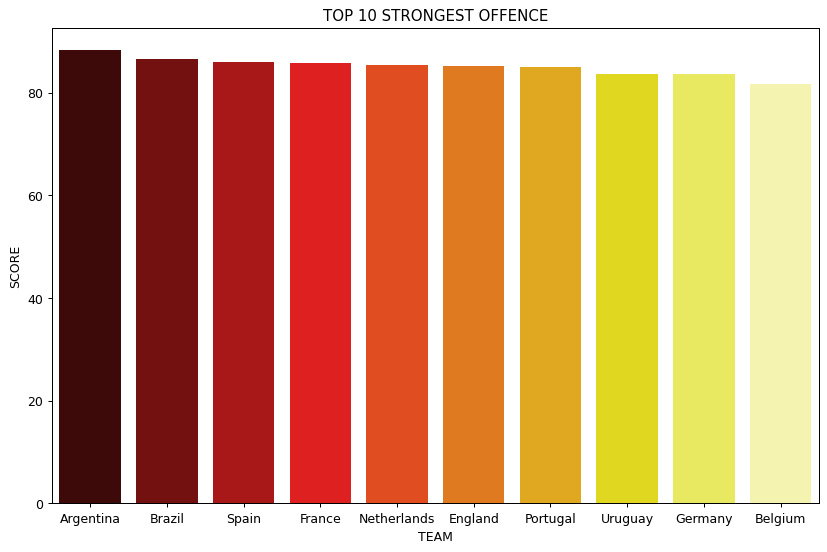

In [ ]:

plt.figure(figsize=(11,7), dpi=90)
ax = sns.barplot(data=offence_scores[:10], x='Team', y='Of score',palette='hot')
plt.xlabel('TEAM')
plt.ylabel('SCORE')
plt.title('TOP 10 STRONGEST OFFENCE');

In [ ]:
midfield_score = []
for x in fifa2022_teams:
    md_score = np.round((fifa2022[fifa2022["home_team"]==x]['home_team_mean_midfield_score'].mean() + 
                         fifa2022[fifa2022["away_team"]==x]['away_team_mean_midfield_score'].mean())/2, 2)
    midfield_score.append(md_score)

midfield_scores = pd.DataFrame({'Team':fifa2022_teams, 'Md score': midfield_score}).sort_values('Md score', ascending=False).reset_index(drop=True)
midfield_scores.index += 1
midfield_scores[:10]

,Team,Md score
1,Spain,87.12
2,France,86.16
3,Germany,85.80
4,Brazil,85.35
5,England,84.52
6,Argentina,84.44
7,Netherlands,83.70
8,Portugal,83.59
9,Belgium,81.52
10,Croatia,81.21


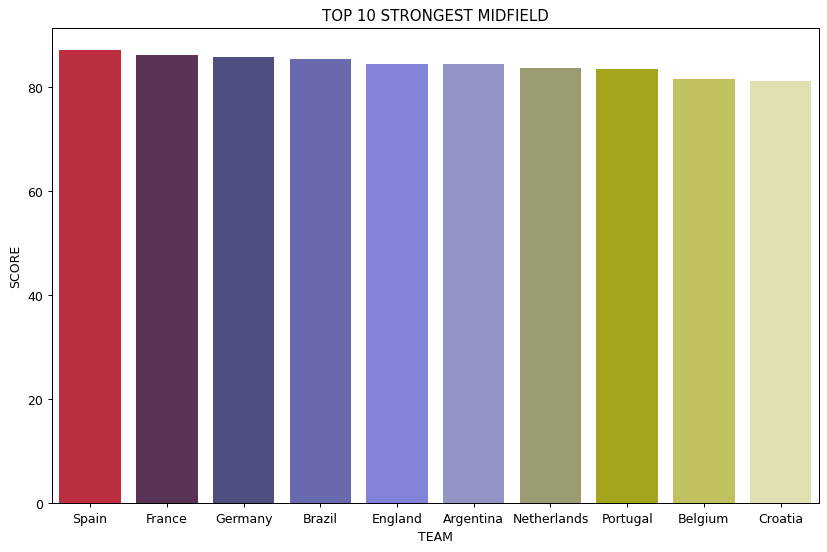

In [ ]:
plt.figure(figsize=(11,7), dpi=90)
ax = sns.barplot(data=midfield_scores[:10], x='Team', y='Md score',palette='gist_stern')
plt.xlabel('TEAM')
plt.ylabel('SCORE')
plt.title('TOP 10 STRONGEST MIDFIELD');

In [ ]:
ranks = []
for x in fifa2022_teams:
    rank_df = fifa2022[(fifa2022['home_team']== x) | (fifa2022['away_team']== x)].sort_values(['date','home_team_fifa_rank','away_team_fifa_rank'], 
                                                                                              ascending=[False,True,True]).iloc[0]
    if rank_df['home_team']==x:
        rank = rank_df['home_team_fifa_rank']
    else:
        rank = rank_df['away_team_fifa_rank']
    ranks.append(rank)

team_ranks = pd.DataFrame({'Team':fifa2022_teams, 'Rank': ranks}).sort_values(['Rank']).reset_index(drop=True)
team_ranks.index += 1
team_ranks[:10]

,Team,Rank
1,Brazil,1
2,Belgium,2
3,France,3
4,Argentina,4
5,England,5
6,Spain,7
7,Portugal,8
8,Mexico,9
9,Netherlands,10
10,Denmark,11


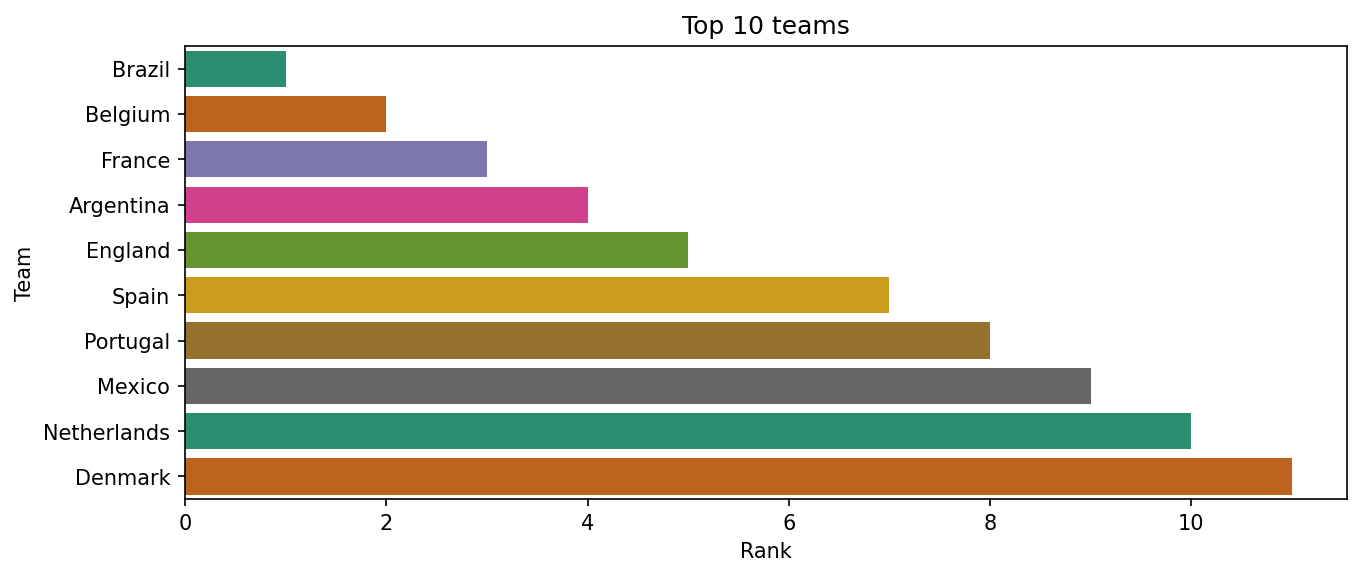

In [ ]:
plt.figure(figsize=(10,4),dpi=150)
sns.barplot(data=team_ranks[:10],y='Team',x='Rank',palette='Dark2')
plt.title("Top 10 teams");

#PRE PROCESSING
UNWANTED COLUM DILITATION
NULL VALUE DILETION
NEW DATAFRAME WITH NEW ADDED COLUMNS

In [ ]:
fifa2022_teams = ['Qatar', 'Ecuador', 'Senegal', 'Netherlands',
                  'England', 'IR Iran', 'USA', 'Wales',
                  'Argentina', 'Saudi Arabia', 'Mexico', 'Poland',
                  'France', 'Australia', 'Denmark', 'Tunisia',
                  'Spain', 'Costa Rica', 'Germany', 'Japan',
                  'Belgium', 'Canada', 'Morocco', 'Croatia',
                  'Brazil', 'Serbia', 'Switzerland', 'Cameroon',
                  'Portugal', 'Ghana', 'Uruguay', 'Korea Republic']

In [ ]:
fifa2022.columns

Index(['date', 'home_team', 'away_team', 'home_team_continent',
       'away_team_continent', 'home_team_fifa_rank', 'away_team_fifa_rank',
       'home_team_total_fifa_points', 'away_team_total_fifa_points',
       'home_team_score', 'away_team_score', 'tournament', 'city', 'country',
       'neutral_location', 'shoot_out', 'home_team_result',
       'home_team_goalkeeper_score', 'away_team_goalkeeper_score',
       'home_team_mean_defense_score', 'home_team_mean_offense_score',
       'home_team_mean_midfield_score', 'away_team_mean_defense_score',
       'away_team_mean_offense_score', 'away_team_mean_midfield_score'],
      dtype='object')

#null value removal

In [ ]:
#Teams are not available in FIFA game itself, 
#so they are not less than average performing teams, 
#so giving a average score of 50 for all.
fifa2022.fillna(50,inplace=True)


In [ ]:

fifa2022.isnull().sum()

date                             0
home_team                        0
away_team                        0
home_team_continent              0
away_team_continent              0
home_team_fifa_rank              0
away_team_fifa_rank              0
home_team_total_fifa_points      0
away_team_total_fifa_points      0
home_team_score                  0
away_team_score                  0
tournament                       0
city                             0
country                          0
neutral_location                 0
shoot_out                        0
home_team_result                 0
home_team_goalkeeper_score       0
away_team_goalkeeper_score       0
home_team_mean_defense_score     0
home_team_mean_offense_score     0
home_team_mean_midfield_score    0
away_team_mean_defense_score     0
away_team_mean_offense_score     0
away_team_mean_midfield_score    0
dtype: int64


#Unwanted data removal

In [ ]:
#Filter the teams participating in World cup 22
list_2022 = ['Qatar', 'Germany', 'Denmark', 'Brazil', 'France', 'Belgium', 'Croatia', 'Spain', 'Serbia', 'England', 
             'Switzerland', 'Netherlands', 'Argentina', 'IR Iran', 'Korea Republic', 'Japan', 'Saudi Arabia', 'Ecuador', 'Uruguay', 'Canada', 
             'Ghana', 'Senegal', 'Portugal', 'Poland', 'Tunisia', 'Morocco', 'Cameroon', 'USA', 'Mexico', 'Wales', 'Australia', 'Costa Rica']
final_dataset =fifa2022[(fifa2022["home_team"].apply(lambda x: x in list_2022)) | (fifa2022["away_team"].apply(lambda x: x in list_2022))]

In [ ]:
#Mapping numeric values for home_team_result to find the correleations
final_dataset['home_team_result'] = final_dataset['home_team_result'].map({'Win':1, 'Draw':2, 'Lose':0})

<ipython-input-21-789fe61696ce>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_dataset['home_team_result'] = final_dataset['home_team_result'].map({'Win':1, 'Draw':2, 'Lose':0})


In [ ]:
#Dropping unnecessary colums
final_dataset = final_dataset.drop(['home_team_continent','away_team_continent', 'tournament', 'city', 'country','neutral_location', 'shoot_out',"date"],axis=1)

In [ ]:
#Changing column names
final_dataset.rename(columns={"home_team":"Team1", "away_team": "Team2", "home_team_fifa_rank": "Team1_FIFA_RANK", 
                         "away_team_fifa_rank":"Team2_FIFA_RANK", 
                         "home_team_result":"Team1_Result", "home_team_goalkeeper_score":"Team1_Goalkeeper_Score",
                        "away_team_goalkeeper_score":"Team2_Goalkeeper_Score", "home_team_mean_defense_score":"Team1_Defense",
                        "home_team_mean_offense_score":"Team1_Offense", "home_team_mean_midfield_score":"Team1_Midfield",
                        "away_team_mean_defense_score":"Team2_Defense", "away_team_mean_offense_score":"Team2_Offense",
                        "away_team_mean_midfield_score":"Team2_Midfield","home_team_total_fifa_points":"Team1_POINTS", 
                        'away_team_total_fifa_points':"Team2_POINTS", 
                        "home_team_score":"Team1_SCORE","away_team_score":"Team2_SCORE"},inplace=True)

In [ ]:
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9321 entries, 0 to 23920
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Team1                   9321 non-null   object 
 1   Team2                   9321 non-null   object 
 2   Team1_FIFA_RANK         9321 non-null   int64  
 3   Team2_FIFA_RANK         9321 non-null   int64  
 4   Team1_POINTS            9321 non-null   int64  
 5   Team2_POINTS            9321 non-null   int64  
 6   Team1_SCORE             9321 non-null   int64  
 7   Team2_SCORE             9321 non-null   int64  
 8   Team1_Result            9321 non-null   int64  
 9   Team1_Goalkeeper_Score  9321 non-null   float64
 10  Team2_Goalkeeper_Score  9321 non-null   float64
 11  Team1_Defense           9321 non-null   float64
 12  Team1_Offense           9321 non-null   float64
 13  Team1_Midfield          9321 non-null   float64
 14  Team2_Defense           9321 non-null  

In [ ]:
final_dataset.columns

Index(['Team1', 'Team2', 'Team1_FIFA_RANK', 'Team2_FIFA_RANK', 'Team1_POINTS',
       'Team2_POINTS', 'Team1_SCORE', 'Team2_SCORE', 'Team1_Result',
       'Team1_Goalkeeper_Score', 'Team2_Goalkeeper_Score', 'Team1_Defense',
       'Team1_Offense', 'Team1_Midfield', 'Team2_Defense', 'Team2_Offense',
       'Team2_Midfield'],
      dtype='object')

#ADDING NEW COLUMNS AND DATA NORMALIZATION

# Feature extraction

In [ ]:

final_dataset['RANK_DIFFERENCE'] = (final_dataset['Team1_FIFA_RANK'] - final_dataset['Team2_FIFA_RANK']).astype("category").cat.codes
final_dataset['AVERAGE_RANK'] = ((final_dataset['Team1_FIFA_RANK'] + final_dataset['Team2_FIFA_RANK'])/2).astype("category").cat.codes
final_dataset['POINT_DIFFERENCE'] = (final_dataset['Team1_POINTS'] - final_dataset['Team2_POINTS']).astype("category").cat.codes

final_dataset['TEAM1'] = (final_dataset['Team1']).astype("category").cat.codes
final_dataset['TEAM2'] = (final_dataset['Team2']).astype("category").cat.codes


In [ ]:
#Create dummies for categorical columns
final_dataset1 = pd.get_dummies(final_dataset)

In [ ]:
final_dataset1


,Team1_FIFA_RANK,Team2_FIFA_RANK,Team1_POINTS,Team2_POINTS,Team1_SCORE,Team2_SCORE,Team1_Result,Team1_Goalkeeper_Score,Team2_Goalkeeper_Score,Team1_Defense,...,Team2_United Arab Emirates,Team2_Uruguay,Team2_Uzbekistan,Team2_Vanuatu,Team2_Venezuela,Team2_Vietnam,Team2_Wales,Team2_Yemen,Team2_Zambia,Team2_Zimbabwe
0,59,22,0,0,3,1,1,50.0,50.0,50.0,...,0,1,0,0,0,0,0,0,0,0
1,8,14,0,0,1,1,2,50.0,50.0,50.0,...,0,0,0,0,0,0,0,0,0,0
2,35,94,0,0,5,0,1,50.0,50.0,50.0,...,0,0,0,0,1,0,0,0,0,0
4,67,5,0,0,1,3,0,50.0,50.0,50.0,...,0,0,0,0,0,0,0,0,0,0
9,4,3,0,0,1,2,0,50.0,50.0,50.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23908,10,18,1658,1588,3,2,1,81.0,74.0,85.2,...,0,0,0,0,0,0,1,0,0,0
23909,26,2,1544,1827,0,1,0,87.0,89.0,75.2,...,0,0,0,0,0,0,0,0,0,0
23918,28,60,1526,1387,0,0,0,79.0,74.0,75.5,...,0,0,0,0,0,0,0,0,0,0
23919,23,35,1553,1499,0,3,0,73.0,50.0,75.2,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
final_dataset1.columns

Index(['Team1_FIFA_RANK', 'Team2_FIFA_RANK', 'Team1_POINTS', 'Team2_POINTS',
       'Team1_SCORE', 'Team2_SCORE', 'Team1_Result', 'Team1_Goalkeeper_Score',
       'Team2_Goalkeeper_Score', 'Team1_Defense',
       ...
       'Team2_United Arab Emirates', 'Team2_Uruguay', 'Team2_Uzbekistan',
       'Team2_Vanuatu', 'Team2_Venezuela', 'Team2_Vietnam', 'Team2_Wales',
       'Team2_Yemen', 'Team2_Zambia', 'Team2_Zimbabwe'],
      dtype='object', length=414)

In [ ]:

final_dataset1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9321 entries, 0 to 23920
Columns: 414 entries, Team1_FIFA_RANK to Team2_Zimbabwe
dtypes: float64(8), int16(5), int64(7), uint8(394)
memory usage: 4.7 MB


# Spliting dataset into Train, Test and Val.

In [ ]:
#split X and y and train test split (For League Matches)

X = final_dataset1.drop('Team1_Result',axis=1)
y = final_dataset1['Team1_Result']

# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

#Validtion and test set
X_hold_test, X_test, y_hold_test, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42)

In [ ]:
X_train.shape, y_train.shape

((6524, 413), (6524,))

In [ ]:
X_test.shape, y_test.shape

((1399, 413), (1399,))

In [ ]:
X_val.shape,y_val.shape 

((2797, 413), (2797,))

In [ ]:
X_hold_test.shape ,y_hold_test.shape

((1398, 413), (1398,))

In [ ]:
#Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_hold_test = scaler.transform(X_hold_test)

In [ ]:
from sklearn import linear_model
from sklearn import ensemble
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix # roc_curve, roc_auc_score
#from sklearn.preprocessing import PolynomialFeatures

# machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
#from sklearn.linear_model import Perceptron
#from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier


In [ ]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
def metrics_display(model):
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test,y_pred))
    ConfusionMatrixDisplay.from_predictions(y_test,y_pred);

              precision    recall  f1-score   support

           0       0.81      0.80      0.81       389
           1       0.82      0.91      0.87       692
           2       0.55      0.43      0.48       318

    accuracy                           0.77      1399
   macro avg       0.73      0.72      0.72      1399
weighted avg       0.76      0.77      0.76      1399



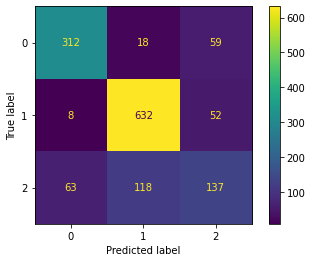

In [ ]:
svc = SVC(probability=True)
metrics_display(svc)

              precision    recall  f1-score   support

           0       0.48      0.63      0.55       389
           1       0.69      0.68      0.69       692
           2       0.29      0.18      0.22       318

    accuracy                           0.56      1399
   macro avg       0.49      0.50      0.49      1399
weighted avg       0.54      0.56      0.54      1399



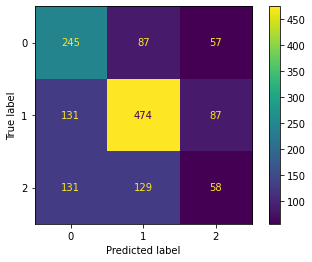

In [ ]:
# KNN
knn = KNeighborsClassifier(n_neighbors = 3)
metrics_display(knn)


              precision    recall  f1-score   support

           0       0.69      0.15      0.24       389
           1       0.91      0.15      0.25       692
           2       0.25      0.93      0.39       318

    accuracy                           0.33      1399
   macro avg       0.61      0.41      0.29      1399
weighted avg       0.70      0.33      0.28      1399



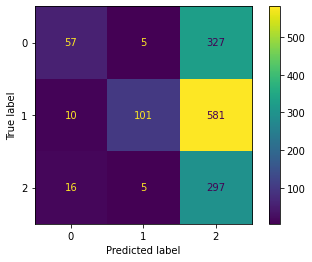

In [ ]:
# Gaussian Naive Bayes

gaussian = GaussianNB()
metrics_display(gaussian)


              precision    recall  f1-score   support

           0       0.97      0.97      0.97       389
           1       0.98      0.98      0.98       692
           2       0.93      0.94      0.93       318

    accuracy                           0.97      1399
   macro avg       0.96      0.96      0.96      1399
weighted avg       0.97      0.97      0.97      1399



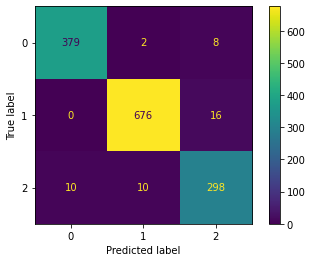

In [ ]:
# Decision Tree

decision_tree = DecisionTreeClassifier() 
metrics_display(decision_tree)


              precision    recall  f1-score   support

           0       0.88      0.94      0.91       389
           1       0.89      0.96      0.92       692
           2       0.84      0.62      0.71       318

    accuracy                           0.87      1399
   macro avg       0.87      0.84      0.85      1399
weighted avg       0.87      0.87      0.87      1399



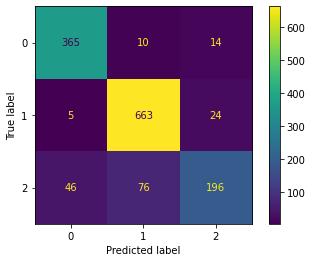

In [ ]:
#Random Forest 
metrics_display(RandomForestClassifier())


/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.99      0.97      0.98       389
           1       0.99      0.97      0.98       692
           2       0.92      0.97      0.95       318

    accuracy                           0.97      1399
   macro avg       0.97      0.97      0.97      1399
weighted avg       0.97      0.97      0.97      1399



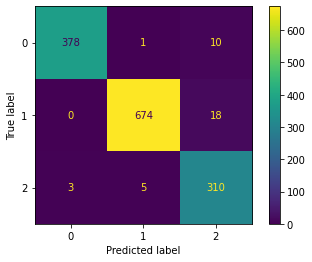

In [ ]:
# LogisticRegression
logreg = LogisticRegression()
metrics_display(logreg)


              precision    recall  f1-score   support

           0       1.00      0.95      0.97       389
           1       0.99      0.96      0.98       692
           2       0.88      0.99      0.93       318

    accuracy                           0.96      1399
   macro avg       0.96      0.97      0.96      1399
weighted avg       0.97      0.96      0.97      1399



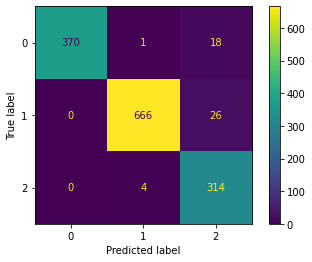

In [ ]:
#Ada Boost Classifier
from sklearn.ensemble import AdaBoostClassifier
metrics_display(AdaBoostClassifier())

              precision    recall  f1-score   support

           0       1.00      0.97      0.99       389
           1       1.00      0.97      0.99       692
           2       0.92      1.00      0.96       318

    accuracy                           0.98      1399
   macro avg       0.97      0.98      0.98      1399
weighted avg       0.98      0.98      0.98      1399



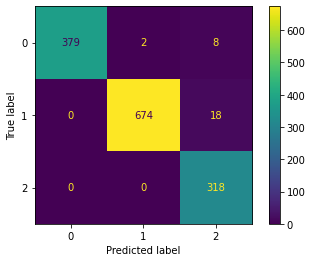

In [ ]:
#XGB Boost
from xgboost import XGBClassifier
metrics_display(XGBClassifier(use_label_encoder=False))

#Neural Network 

In [ ]:
X_train.shape

(6524, 413)

Epoch 1/10
164/164 [==============================] - 2s 9ms/step - loss: 0.9255 - accuracy: 0.5808 - val_loss: 0.7166 - val_accuracy: 0.6950
Epoch 2/10
164/164 [==============================] - 1s 8ms/step - loss: 0.5928 - accuracy: 0.7367 - val_loss: 0.4375 - val_accuracy: 0.8284
Epoch 3/10
164/164 [==============================] - 1s 8ms/step - loss: 0.3936 - accuracy: 0.8454 - val_loss: 0.3664 - val_accuracy: 0.8644
Epoch 4/10
164/164 [==============================] - 1s 8ms/step - loss: 0.2874 - accuracy: 0.8971 - val_loss: 0.2505 - val_accuracy: 0.9142
Epoch 5/10
164/164 [==============================] - 1s 8ms/step - loss: 0.2199 - accuracy: 0.9193 - val_loss: 0.2105 - val_accuracy: 0.9341
Epoch 6/10
164/164 [==============================] - 1s 8ms/step - loss: 0.1981 - accuracy: 0.9297 - val_loss: 0.2144 - val_accuracy: 0.9326
Epoch 7/10
164/164 [==============================] - 1s 8ms/step - loss: 0.1511 - accuracy: 0.9481 - val_loss: 0.2283 - val_accuracy: 0.9326
Epoch 

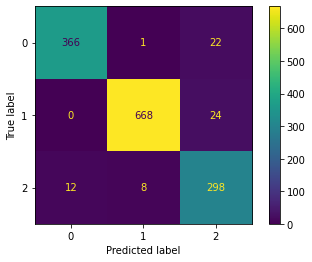

In [ ]:
#simple Neural network
import keras
from keras import Sequential
from keras.layers import Dense,Dropout
from keras import Input

model = Sequential()
model.add(Input(shape=(413,)))
model.add(Dense(300,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(200,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(100,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3,activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train,y_train,epochs=10,validation_split=0.2)

y_pred1 = model.predict(X_test)
y_pred1 = np.argmax(y_pred1,axis=1)
print(classification_report(y_test,y_pred1))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred1)

# XGB Classifier is giving better results than others. 
#So, now evaluting the XGB Classifier using val dataset.

              precision    recall  f1-score   support

           0       1.00      0.97      0.99       394
           1       1.00      0.99      0.99       666
           2       0.95      0.99      0.97       338

    accuracy                           0.99      1398
   macro avg       0.98      0.99      0.98      1398
weighted avg       0.99      0.99      0.99      1398



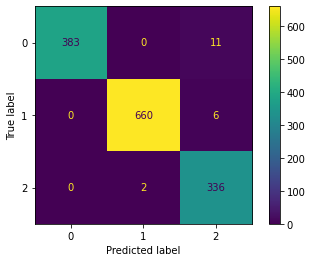

In [ ]:
XGB = XGBClassifier(probability=True)
XGB.fit(X_train,y_train)
y_pred = XGB.predict(X_hold_test)
print(classification_report(y_hold_test,y_pred))
ConfusionMatrixDisplay.from_predictions(y_hold_test,y_pred);

# Evaluation part

In [ ]:
world_cup_rankings_home = final_dataset.groupby('Team1').mean()
world_cup_rankings_away = final_dataset.groupby('Team2').mean()

In [ ]:
from tqdm import tqdm #SHOW TASK BAR

simulation_winners = list()
simulation_results_winners = list()
simulation_results_round16 = list()
simulation_df_round16 = list()
simulation_results_quarterfinal = list()
simulation_df_quarterfinal = list()
simulation_results_semifinal = list()
simulation_df_semifinal = list()

n_simulations = 1000 

for j in tqdm(range(n_simulations)):
  
    candidates = [ 'Senegal', 'Netherlands', 'England','USA', 'Argentina', 'Poland', 
              'France', 'Denmark','Spain', 'Germany', 'Belgium', 'Croatia', 'Brazil', 'Serbia', 'Portugal','Uruguay']
    finals = ['round_of_16', 'quarterfinal', 'semifinal', 'final']
    
    for f in finals:
        iterations = int(len(candidates) / 2)
        winners = []
        prob = []


        for i in range(iterations):
            home = candidates[i*2]
            away = candidates[i*2+1]
            
            #row = pd.DataFrame(np.array([[np.nan, np.nan, True]]), columns=X_test.columns)
            home_rank = world_cup_rankings_home.loc[home, 'Team1_FIFA_RANK']
            home_points = world_cup_rankings_home.loc[home, 'Team1_POINTS']
            opp_rank = world_cup_rankings_away.loc[away, 'Team2_FIFA_RANK']
            opp_points = world_cup_rankings_away.loc[away, 'Team2_POINTS']
            final_dataset['AVERAGE_RANK'] = (home_rank + opp_rank) / 2
            final_dataset['RANK_DIFFERENCE'] = home_rank - opp_rank
            final_dataset['POINT_DIFFERENCE'] = home_points - opp_points
            home_win_prob = XGB.predict_proba(X_hold_test)[:,1][0]
            
            # simulation step based on the probability
            simulated_outcome = np.random.binomial(1, home_win_prob)
            winners.append(away) if simulated_outcome <= 0.5 else winners.append(home)
            prob.append(1 - simulated_outcome) if simulated_outcome <= 0.5 else prob.append(simulated_outcome)
        
        if f == 'round_of_16':
            step_16 = ['round_16'] * 8
            candidates_round_16 = zip(step_16, winners, prob)
            df_candidates_round_16 = pd.DataFrame(candidates_round_16, columns = ['Step','Team','Prob'])
            simulation_df_round16.append(df_candidates_round_16)
            simulation_results_round16.append(winners)

        if f == 'quarterfinal':
            step_quarterfinal = ['quarterfinal'] * 4
            candidates_quarterfinal = zip(step_quarterfinal,winners, prob)
            df_candidates_quarterfinal = pd.DataFrame(candidates_quarterfinal, columns = ['Step','Team','Prob'])
            simulation_df_quarterfinal.append(df_candidates_quarterfinal)
            simulation_results_quarterfinal.append(winners)

        if f == 'semifinal':    
            step_semifinal = ['semifinal'] * 2
            candidates_semifinal = zip(step_semifinal,winners, prob)
            df_candidates_semifinal = pd.DataFrame(candidates_semifinal, columns = ['Step','Team','Prob'])
            simulation_df_semifinal.append(df_candidates_semifinal)
            simulation_results_semifinal.append(winners)

        if f == 'final':    
            step_final = ['final'] * 1
            candidates_final = zip(step_final,winners, prob)
            df_candidates_final = pd.DataFrame(candidates_final, columns = ['Step','Team','Prob'])
            simulation_winners.append(df_candidates_final)
            simulation_results_winners.append(winners)

        

        candidates = winners 

df_candidates_round_16 = pd.concat(simulation_df_round16)
df_candidates_quarterfinal = pd.concat(simulation_df_quarterfinal)
df_candidates_semifinal = pd.concat(simulation_df_semifinal)
df_candidates_final = pd.concat(simulation_winners)

df_results = pd.concat([df_candidates_round_16,df_candidates_quarterfinal,df_candidates_semifinal,df_candidates_final]) #final DataFrame

simulation_results_round16 = sum(simulation_results_round16, [])
simulation_results_quarterfinal = sum(simulation_results_quarterfinal, [])
simulation_results_semifinal = sum(simulation_results_semifinal, [])
simulations_winners = sum(simulation_results_winners, [])


100%|██████████| 1000/1000 [06:19<00:00,  2.64it/s]


In [ ]:
#Counter is used to easily count recurrent elements in a list 
from collections import Counter
from matplotlib import figure

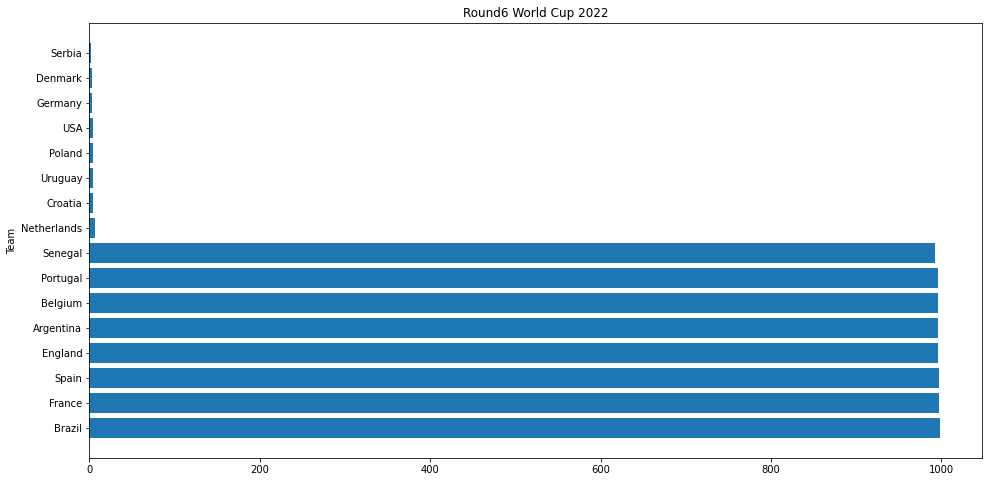

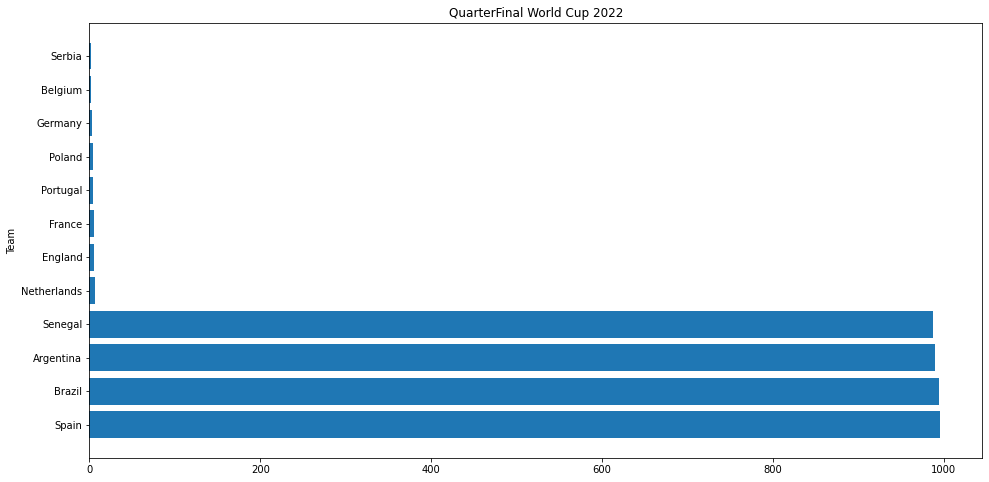

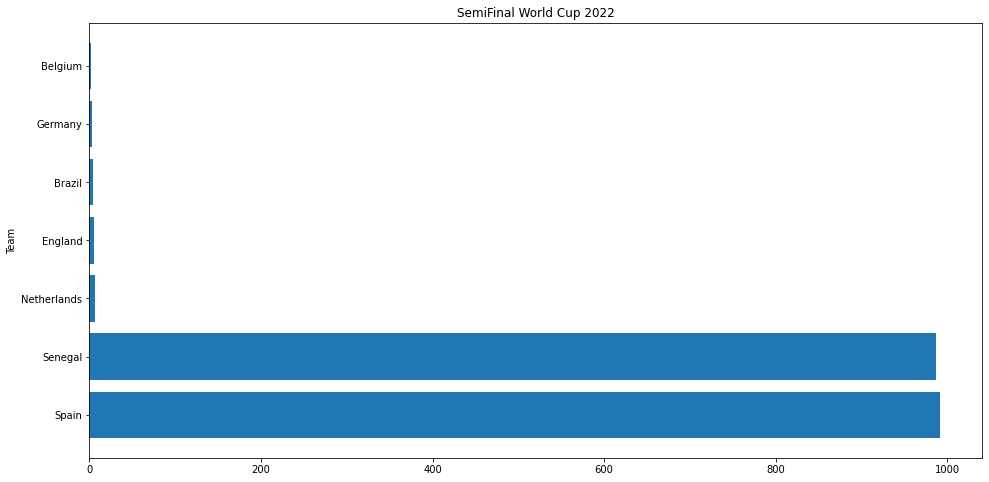

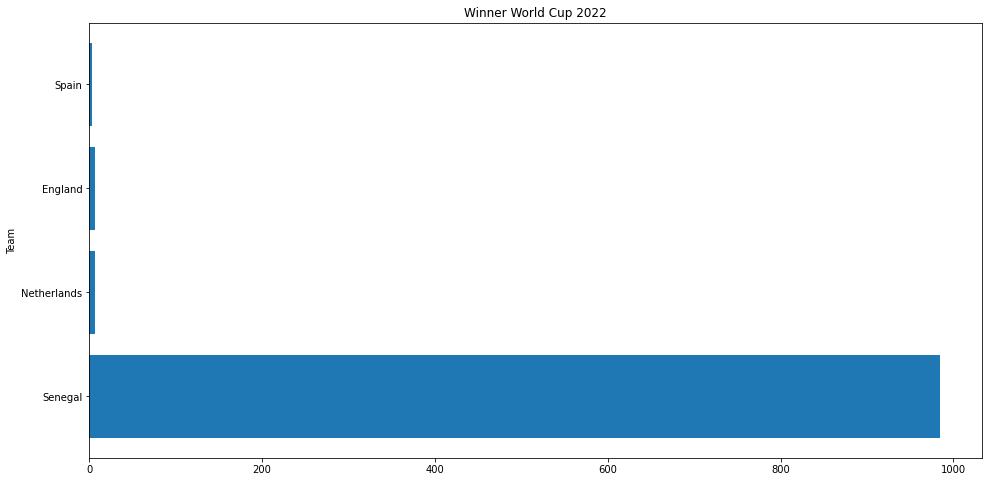

In [ ]:
lst_results = [simulation_results_round16,simulation_results_quarterfinal,simulation_results_semifinal,simulations_winners]
for i in lst_results:
    results = Counter(i).most_common()
    x,y = zip(*results)

    fig,ax = plt.subplots(figsize=(16,8))

    ax.barh(x, y)

    ax.set_ylabel('Team')

    if i == simulation_results_round16:
        ax.set_title('Round6 World Cup 2022')
    if i == simulation_results_quarterfinal:
        ax.set_title('QuarterFinal World Cup 2022')
    if i == simulation_results_semifinal:
        ax.set_title('SemiFinal World Cup 2022')
    if i == simulations_winners:
        ax.set_title('Winner World Cup 2022')

        
    plt.show()